In [1]:
import pandas as pd
import os
import polars as pl
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance


helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

In [3]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None
        
    print(f"Loading Signal: {mode_str}... from {file_path}")
    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    # 3. Rename columns to map directly to your SR data features
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt", # Or keep "met" if your main SR data uses "met" instead
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    # 4. Convert to Polars DataFrame to match your df_mc and df_data

    print(f"  -> Loaded {len(df_sim)} generated events.")
    print(f"  -> Total expected yield (Lumi = {LUMI} fb^-1): {df_sim['final_weight'].sum():.2f} events.")
    
    return df_sim


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_signal_events(signal_events, weight_col):
    print(f"Signal events shape: {signal_events.shape}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        # Signal
        signal_arr = signal_events[var].to_numpy()
        signal_weights = signal_events[weight_col].to_numpy()
        counts_sig, _ = np.histogram(signal_arr, bins=bins, weights=signal_weights)

        plt.stairs(counts_sig, bins, fill = True, color= 'red')

        plt.show()

def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    if scale:
        df.loc[:, features_to_scale] = scaler.transform(df[features_to_scale].values).astype('float32')
    else:
        df.loc[:, features_to_scale] = scaler.inverse_transform(df[features_to_scale].values).astype('float32')
        
    return df

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values
    # print(sig_events_to_score.shape)
    all_scores = []
    # Load model
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)
        # print(len(scores_sig))
    # print(len(np.median(all_scores, axis = 0)))
    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df


def bkg_score_plot(
    df_data, 
    df_bkg, 
    data_score_colname, 
    bkg_score_colname, 
    bkg_weight_name,
    bins=50, 
    figsize=(8, 5)
):
    bkg_name = data_score_colname.split("_")[-1].title()
    

    plt.figure(figsize=figsize)
    
    # Clean missing values
    data_scores = df_data[data_score_colname].dropna()
    bkg_scores = df_bkg[bkg_score_colname].dropna()
    
    # Force identical bin edges across both distributions
    min_val = 0
    max_val = 1
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Plot background
    plt.hist(
        bkg_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#1f77b4", 
        edgecolor="#1f77b4",
        label=bkg_name,
        histtype="stepfilled", 
        weights=df_bkg[bkg_weight_name]
    )
    
    plt.hist(
        data_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#d62728", 
        edgecolor="#d62728",
        label="Data",
        histtype="stepfilled"
    )
    
    # Formatting
    plt.xlabel("Classifier Score", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.title(f"Classifier Score Distribution: Data vs. {bkg_name} Background", fontsize=12, fontweight="bold")
    
    # if log_scale:
    plt.yscale("log")
        
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)
    plt.tight_layout()
    plt.show()

def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [5]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

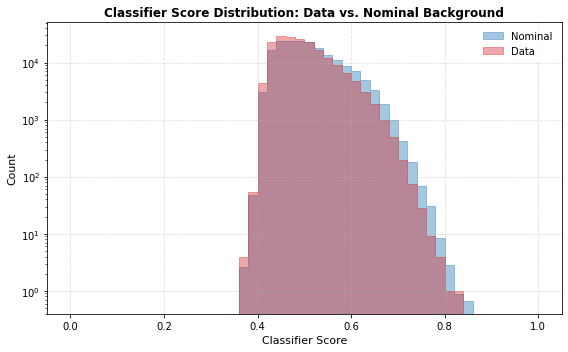

In [6]:
bkg_score_plot(df_data, df_mc_rw, "score_vs_nominal", "score_vs_data", "final_weight")

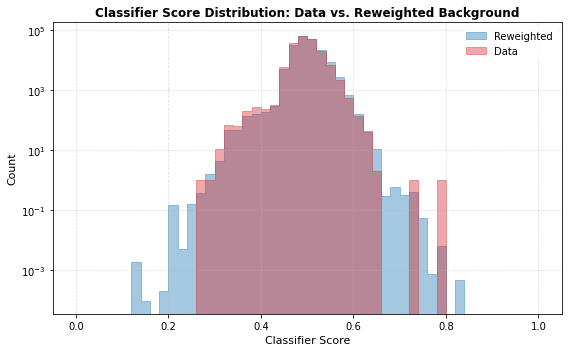

In [7]:
bkg_score_plot(df_data, df_mc_rw, "score_vs_reweighted", "score_vs_reweighted_data", "rw_mediam_weights")

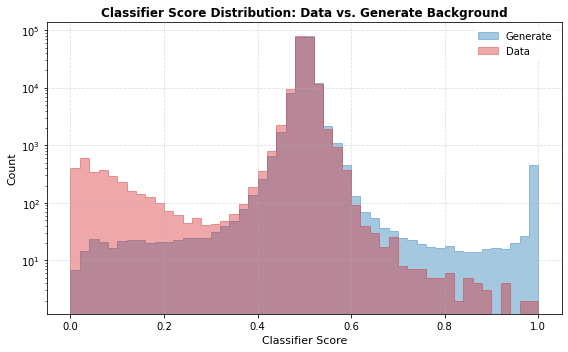

In [8]:
bkg_score_plot(df_data, df_mc_gen, "score_vs_generate", "score_vs_data", "total_weight")

In [9]:
SIGNAL_MODES = [
    "1000_2",
    "1000_4",
    "1000_6",
    "1000_8",
    "2000_2",
    "2000_4",
    "2000_6",
    "2000_8",
    "3000_2",
    "3000_4",
    "3000_6",
    "3000_8"
]

In [10]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

Loading Signal: 1000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_2_default.parquet
  -> Loaded 3027 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 7338.88 events.
Loading Signal: 1000_4... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_4_default.parquet
  -> Loaded 6949 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 16828.26 events.
Loading Signal: 1000_6... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_6_default.parquet
  -> Loaded 11480 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 27835.87 events.
Loading Signal: 1000_8... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_8_default.parquet
  -> Loaded 16409 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 39795.68 events.
Loading Signal: 2000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_v

In [11]:
def plot_sig_kin(df_data, df_bkg, df_sig, bkg_type, sig_mode):

    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    row1_vars = ['ht', 'met', 'score']
    row2_vars = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

    log_vars = ['mjj', 'ht', 'met', 'score']
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'score': f'Anomaly Score ({bkg_type})',
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    fig = plt.figure(figsize=(24, 12))

    gs_outer = fig.add_gridspec(2, 1, hspace=0.35)

    gs_top = gs_outer[0].subgridspec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.25)
    gs_bot = gs_outer[1].subgridspec(2, 5, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    def draw_variable(var, gs_inner, col_idx):
        if var == "score":
            density = True
            bins = np.arange(0, 1, 1/50)
        else:
            density = False
            bins = np.arange(-3, 3, 0.25)
        d_col = data_col_score if var == 'score' else var
        b_col = bkg_col_score if var == 'score' else var
        s_col = sig_col_score if var == 'score' else var
        
        var_name = var
        if d_col not in df_data.columns and var == 'met' and 'met_recalc_pt' in df_data.columns:
            d_col, b_col, s_col = 'met_recalc_pt', 'met_recalc_pt', 'met_recalc_pt'
            var_name = 'met_recalc_pt'

        data_arr = df_data[d_col].to_numpy()
        bkg_arr = df_bkg[b_col].to_numpy()
        sig_arr = df_sig[s_col].to_numpy()
        bkg_weights = df_bkg[bkg_weight_name].to_numpy()
        sig_weights = df_sig["final_weight"]

        bin_centers = (bins[:-1] + bins[1:]) / 2

        ax_main = fig.add_subplot(gs_inner[0, col_idx])
        ax_ratio = fig.add_subplot(gs_inner[1, col_idx], sharex=ax_main)

        # --- DATA ---
        counts_data, _ = np.histogram(data_arr, bins=bins, density=density)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        valid = counts_data > 0
        
        if var == "score":
            ax_main.errorbar(bin_centers, counts_data, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        else:    
            ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # --- BACKGROUND ---
        counts_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights, density=density)
        ax_main.stairs(counts_bkg, bins, fill=True, color="grey", alpha=0.5, label=f'SM Background')
        
        ratio_bkg = np.divide(counts_bkg, counts_data, out=np.full_like(counts_bkg, np.nan, dtype=float), where=valid)
        ax_ratio.stairs(ratio_bkg, bins, color="grey", alpha=0.8)

        # --- SIGNAL ---
        counts_sig, _ = np.histogram(sig_arr, bins=bins, weights=sig_weights, density=density)
        ax_main.stairs(counts_sig, bins, color="red", linewidth=2, linestyle='-', label='Signal (BSM)')


        if var in log_vars:
            ax_main.set_yscale('log')

        ymin, ymax = ax_main.get_ylim()
        if var in log_vars:

            ax_main.set_ylim(ymin, ymax) 
        else:
            ax_main.set_ylim(ymin, ymax * 1.5)

        if col_idx == 0:
            ax_main.set_ylabel('Events', fontsize=12)
            ax_ratio.set_ylabel('Bkg/Data', fontsize=10)
        
        ax_main.legend(frameon=False, fontsize=9, loc='upper right')
        plt.setp(ax_main.get_xticklabels(), visible=False) # Hide x-ticks on main plot

        ax_ratio.set_ylim(0.5, 1.5) 
        ax_ratio.set_xlabel(pretty_labels.get(var_name, var_name), fontsize=12)
        ax_ratio.tick_params(axis='x', which='both', bottom=True, top=True)
        ax_ratio.grid(True, axis='y', linestyle=':', alpha=0.6)


    for i, var in enumerate(row1_vars):
        draw_variable(var, gs_top, i)
        

    for i, var in enumerate(row2_vars):
        draw_variable(var, gs_bot, i)

    title_text = (
        r"Kinematic Distributions ($M_\phi = "
        + str(sig_mode.split("_")[0])
        + r"\text{ GeV}$, $R_{\text{inv}} = 0."
        + str(sig_mode.split("_")[1])
        + r"$)"
    )

    fig.suptitle(title_text, fontsize=20, fontweight="bold", y=0.95)
    plt.show()

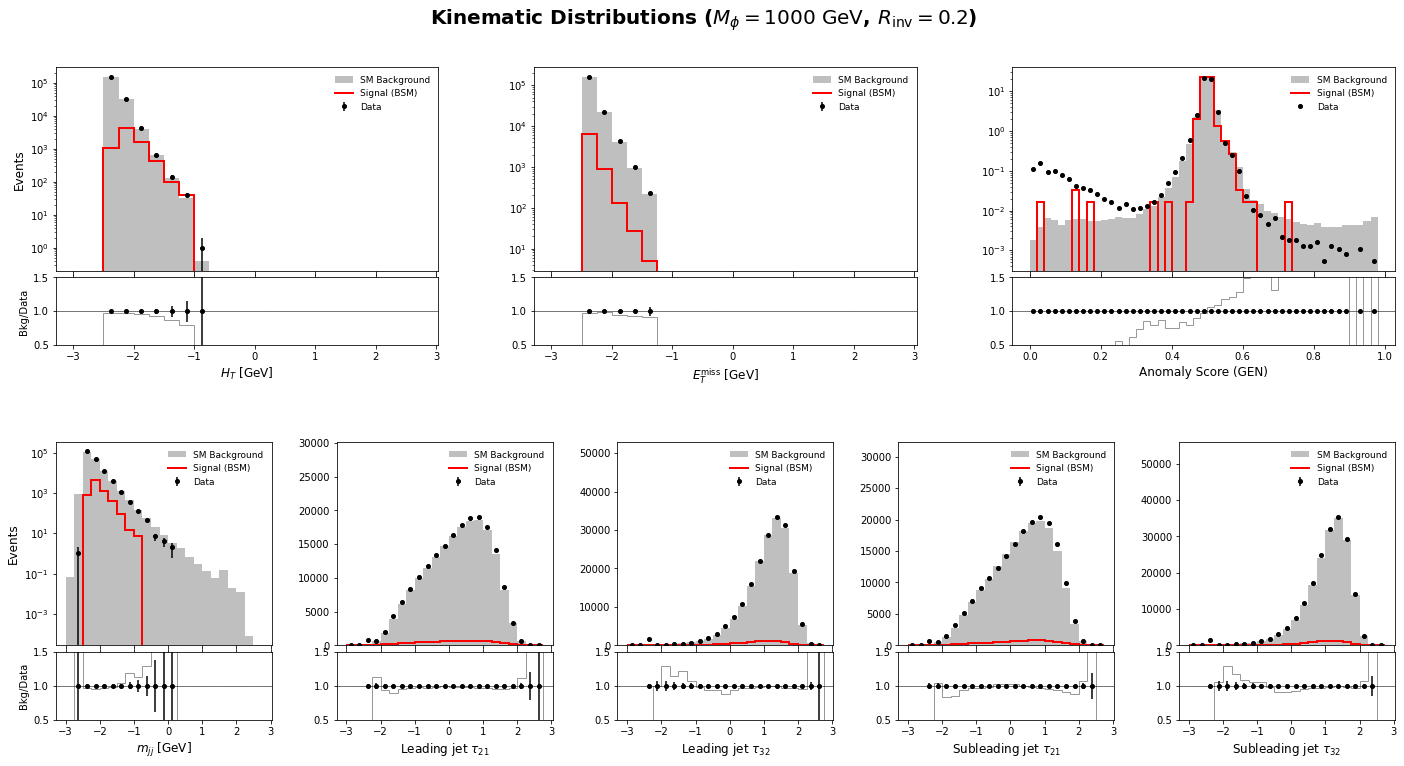

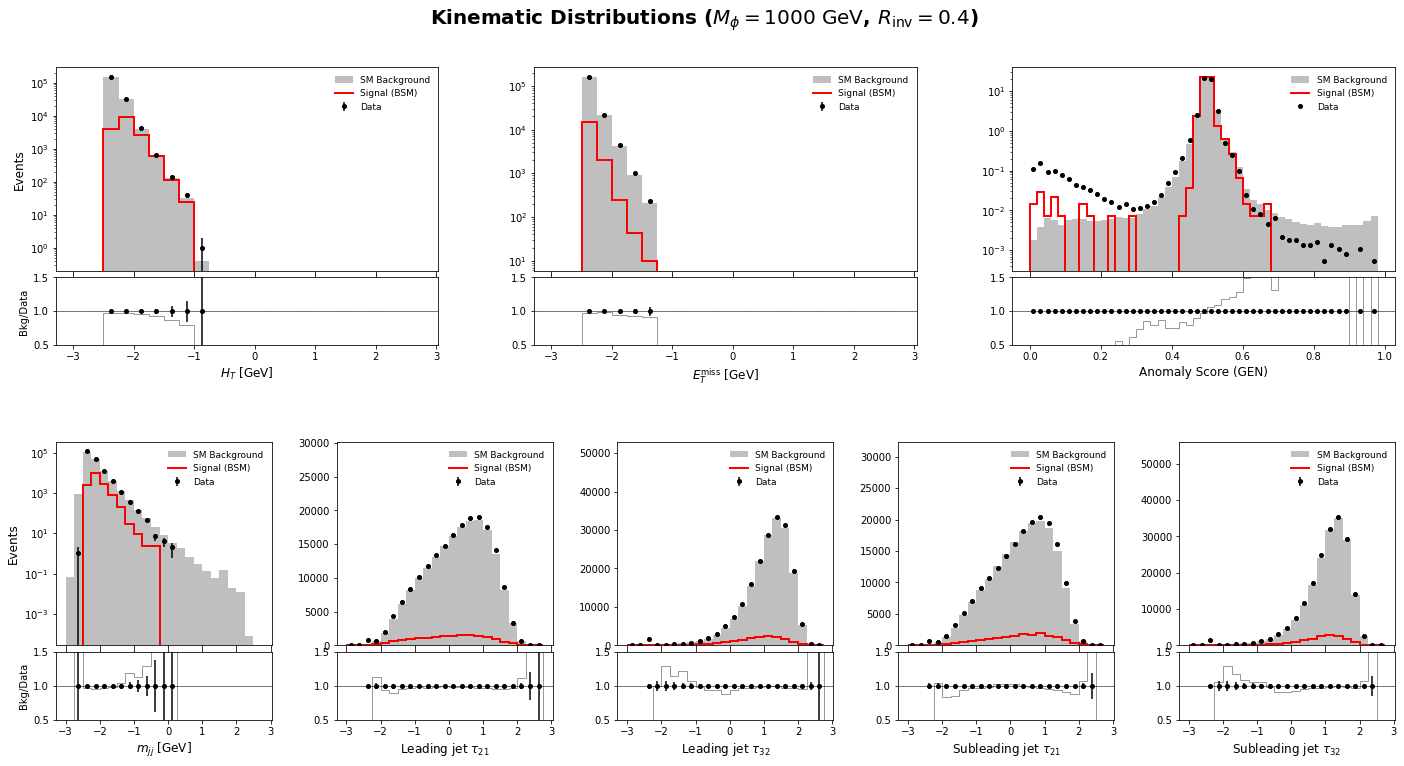

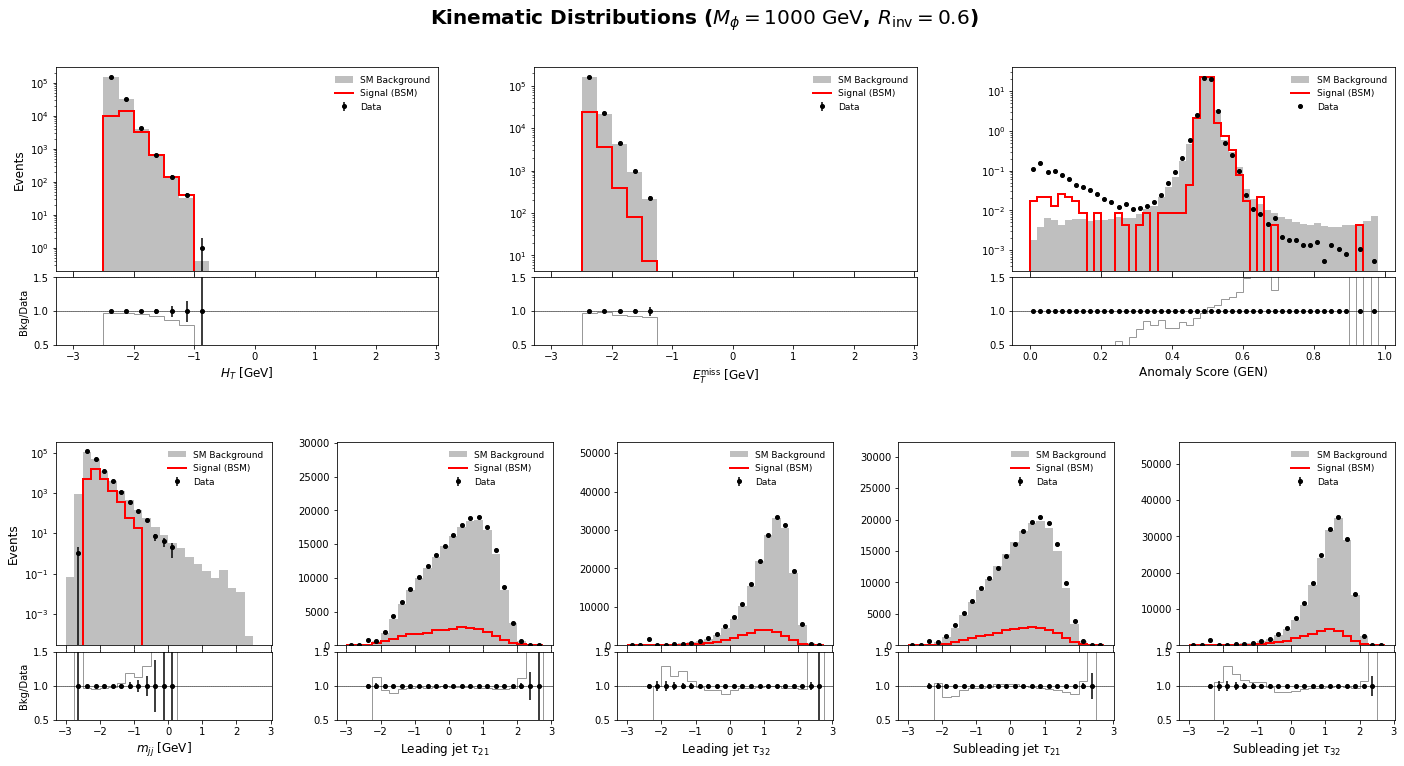

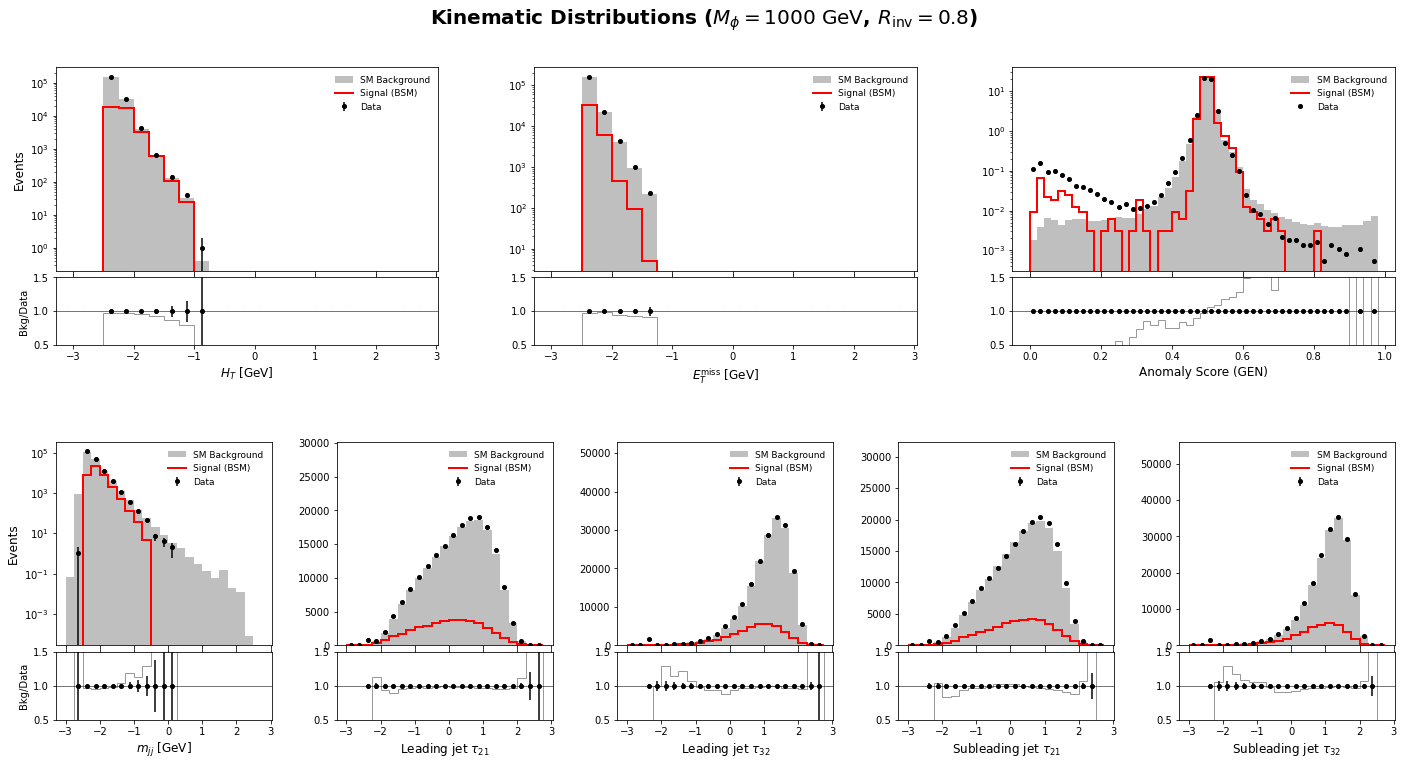

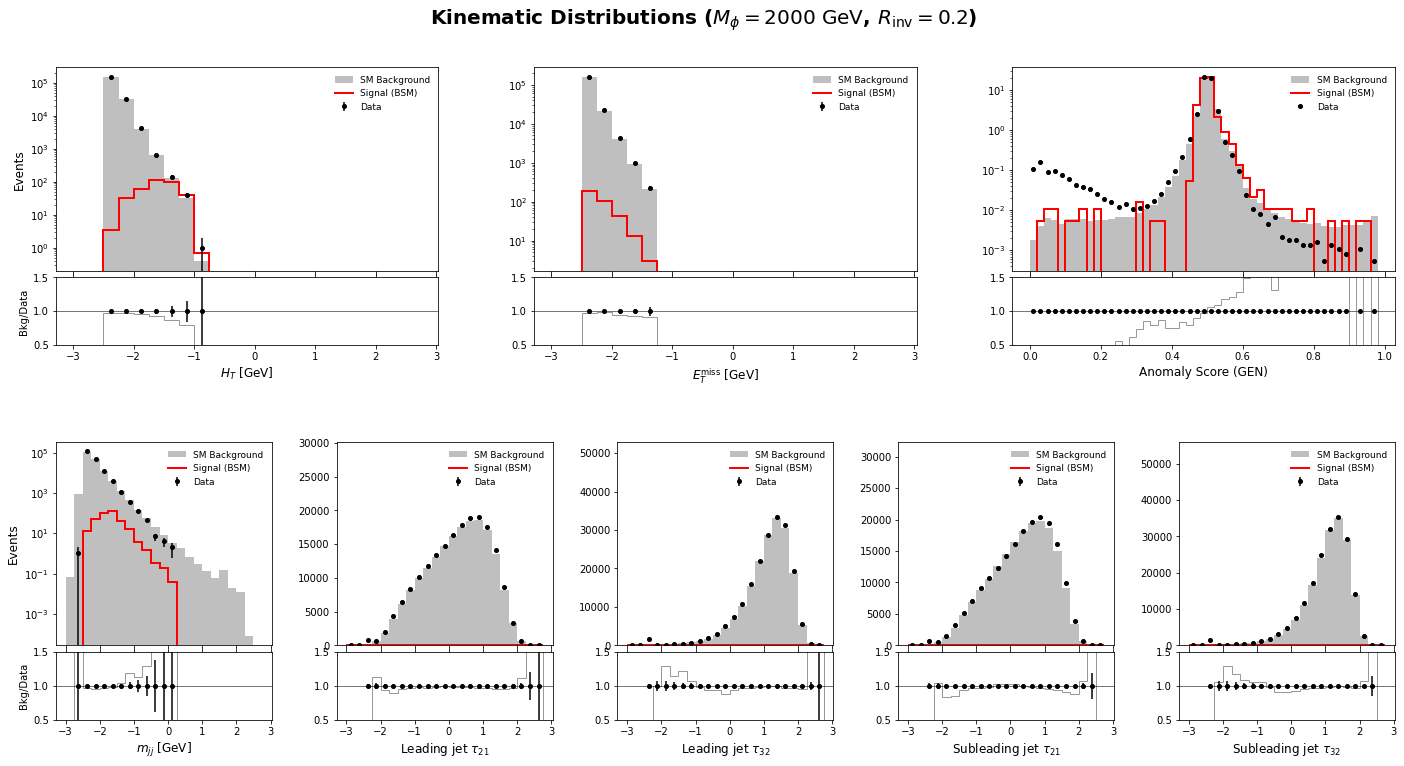

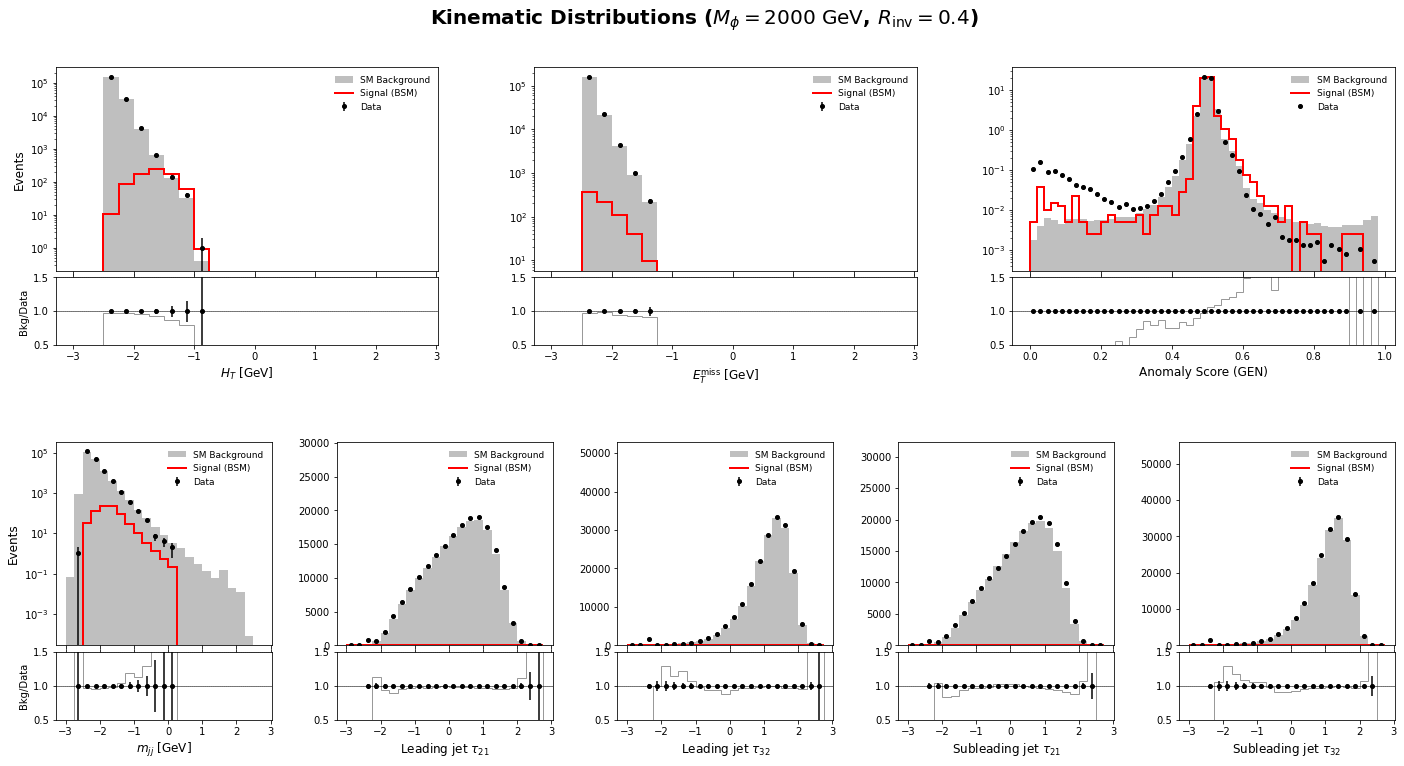

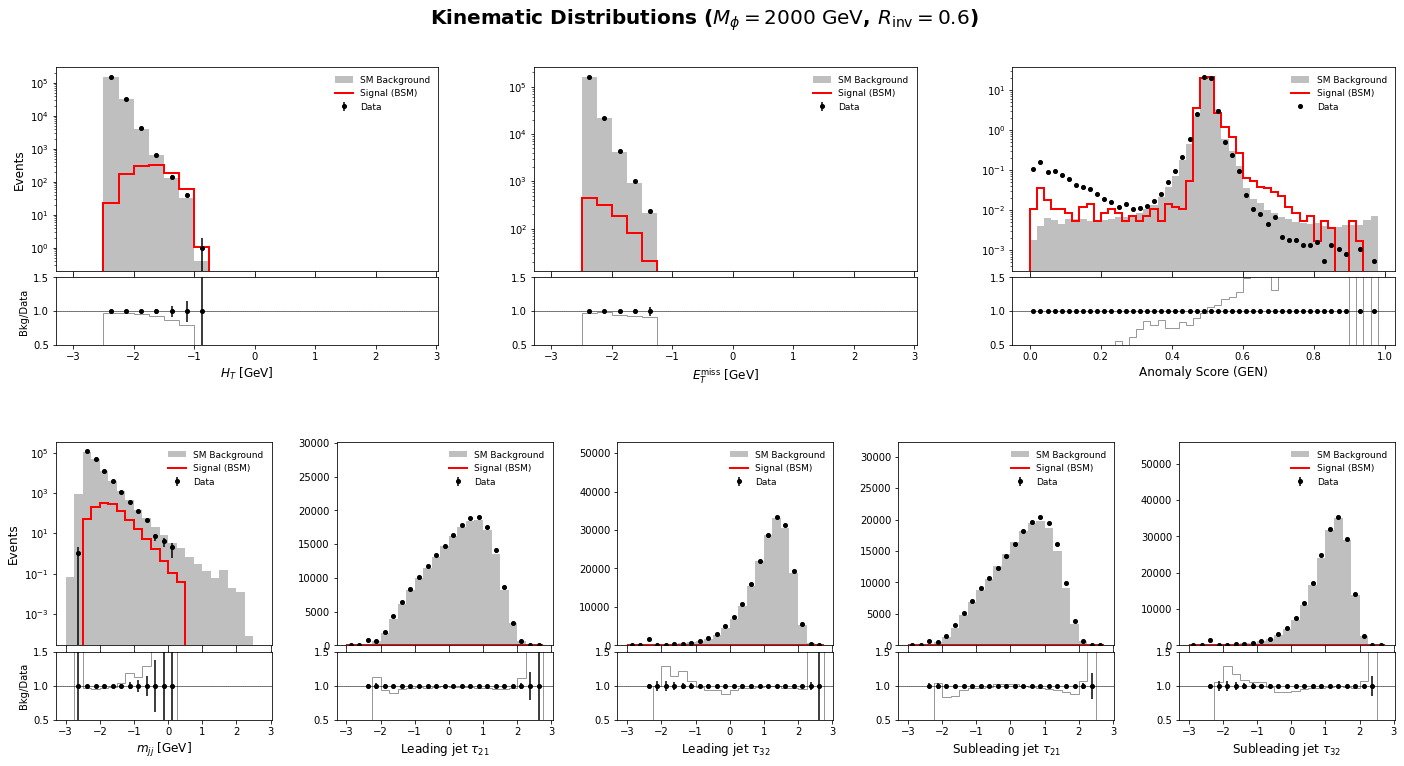

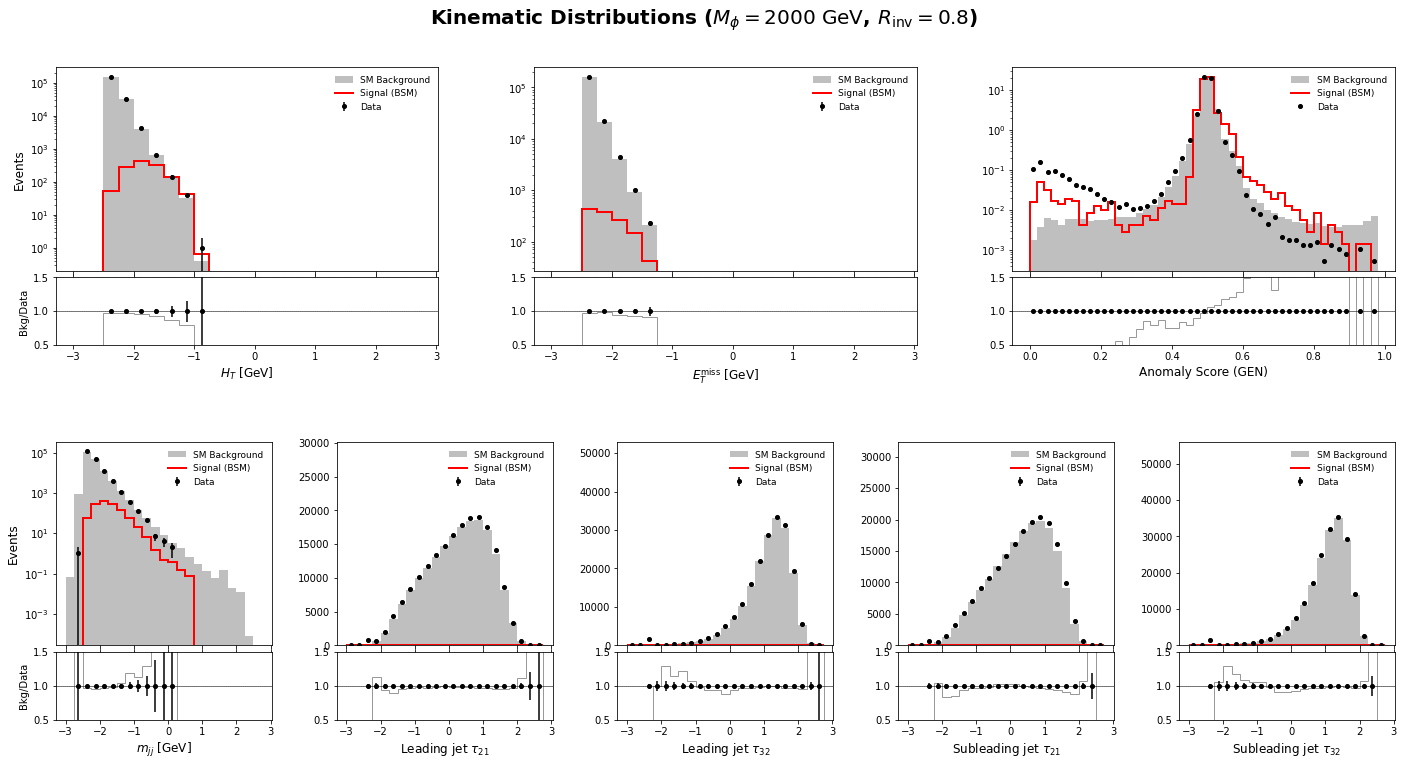

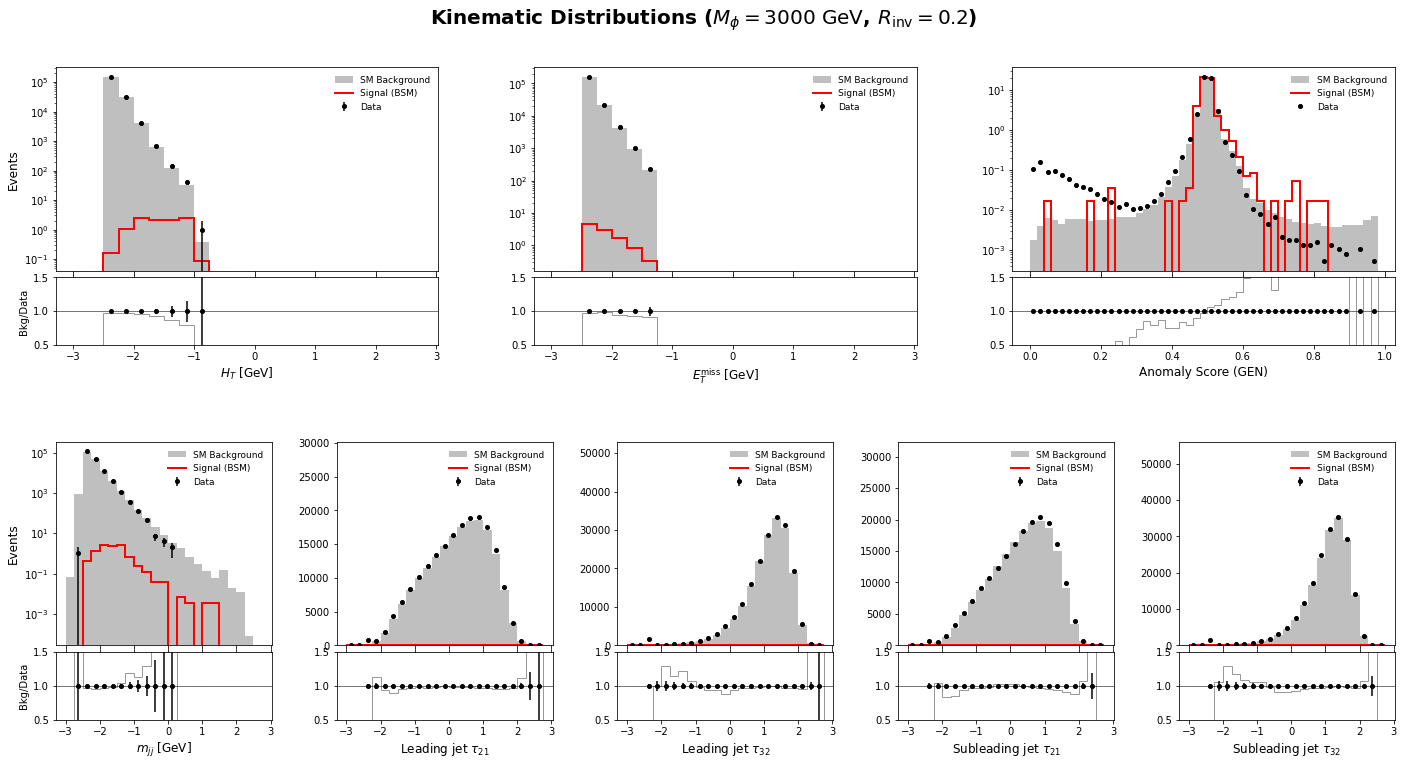

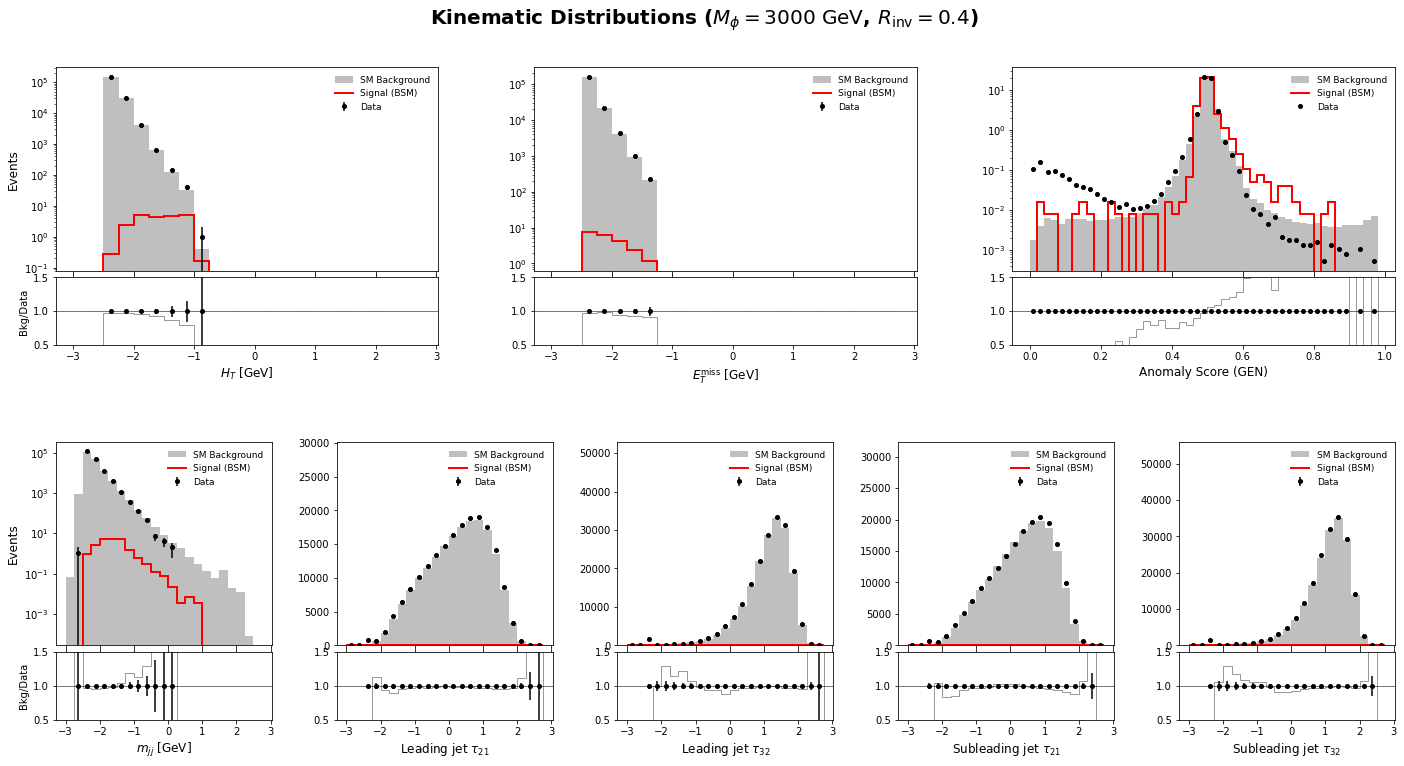

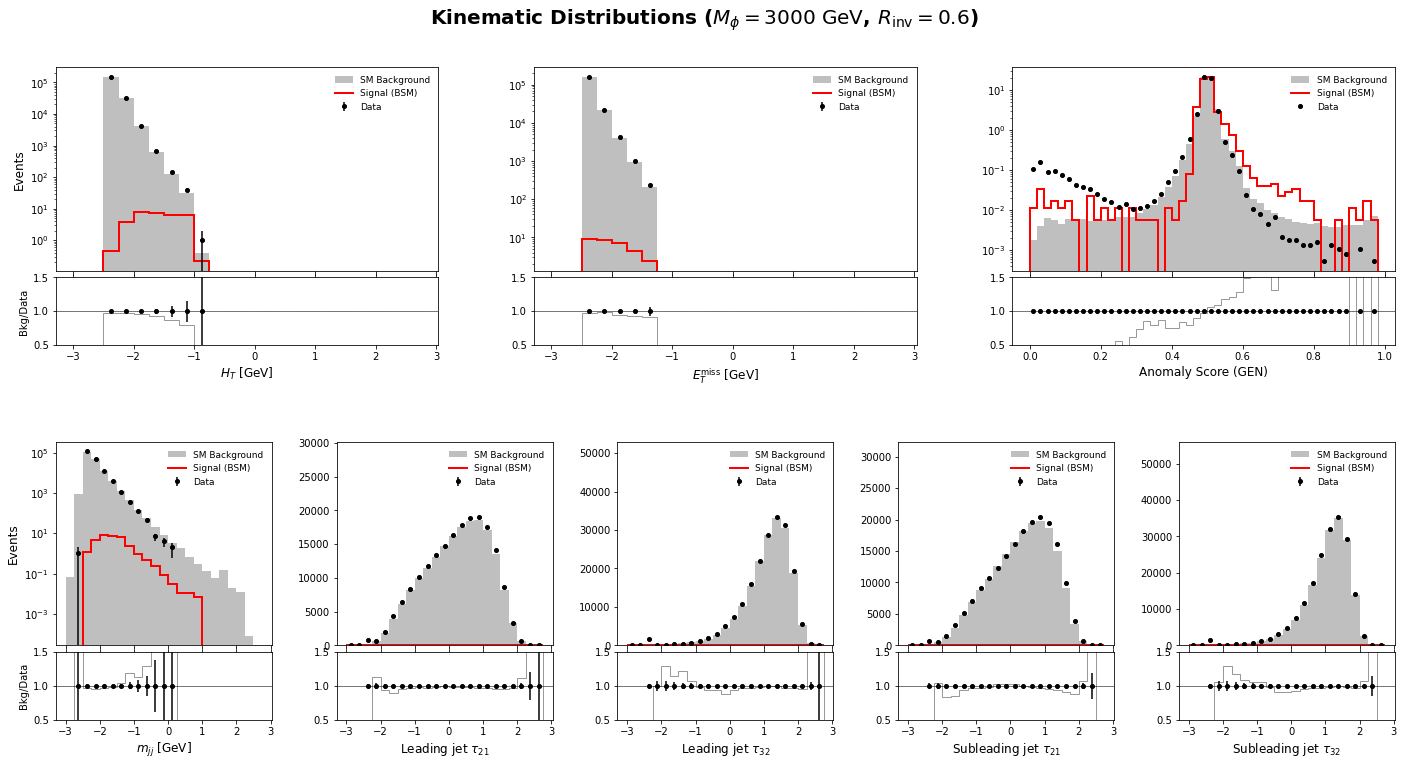

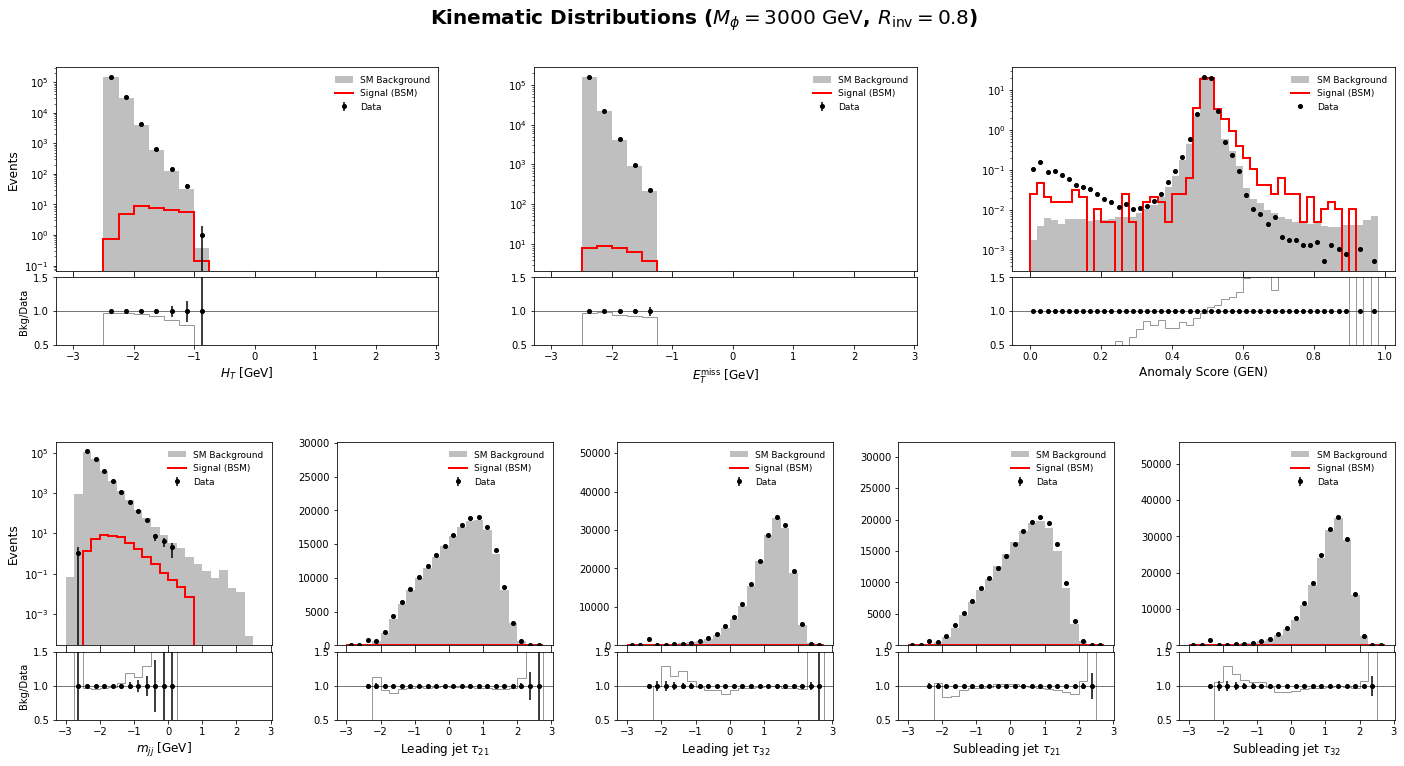

In [12]:
detector_type = "default" # default, pu, run2, pu_run2
bkg_type = "GEN" # NOM, RW, GEN
df_sig_def = sig_dfs[detector_type]

for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
    else:
        df_mc = df_mc_rw
    plot_sig_kin(df_data, df_mc, df_sig_def[sig_mode], bkg_type=bkg_type, sig_mode = sig_mode)

In [17]:
def plot_sr_closure(df_data, df_bkg, bkg_type, feature, threshold):
    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "final_weight"
        bkg_label = "Nominal MC"
        color = "#1f77b4" # Blue
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        bkg_weight_name = "rw_mediam_weights"
        bkg_label = "Reweighted (SALAD-like)"
        color = "#2ca02c" # Green
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "total_weight"
        bkg_label = "Generated (CATHODE-like)"
        color = "#ff7f0e" # Orange
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")


    data_events = df_data[df_data[data_col_score] > threshold]
    bkg_events = df_bkg[df_bkg[bkg_col_score] > threshold]

    f_data = data_events[feature].dropna().values
    f_bkg = bkg_events[feature].dropna().values
    w_bkg = bkg_events[bkg_weight_name].loc[bkg_events[feature].dropna().index].values

    valid_range = (-3.0, 3.0)
    
    data_mask = (f_data >= valid_range[0]) & (f_data <= valid_range[1])
    f_data_clean = f_data[data_mask]
    
    bkg_mask = (f_bkg >= valid_range[0]) & (f_bkg <= valid_range[1])
    f_bkg_clean = f_bkg[bkg_mask]
    w_bkg_clean = w_bkg[bkg_mask]

    wd = wasserstein_distance(
        f_data_clean, 
        f_bkg_clean, 
        u_weights=None, 
        v_weights=np.abs(w_bkg_clean)
    )


    bin_edges = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


    counts_data, _ = np.histogram(f_data, bins=bin_edges)
    counts_bkg, _ = np.histogram(f_bkg, bins=bin_edges, weights=w_bkg)

    err_data = np.sqrt(counts_data)
    err_bkg = np.sqrt(np.histogram(f_bkg, bins=bin_edges, weights=w_bkg**2)[0])


    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 7), sharex=True, 
        gridspec_kw={'height_ratios': [3, 1]}
    )

    ax1.hist(
        f_bkg, bins=bin_edges, weights=w_bkg,
        alpha=0.5, color=color, label=bkg_label, histtype="stepfilled"
    )
    ax1.errorbar(
        bin_centers, counts_data, yerr=err_data, 
        fmt='ko', label=f"Data (Score > {threshold:.3f})", capsize=2, elinewidth=1
    )
    
    ax1.text(
        0.05, 0.95, f"Wasserstein Dist: {wd:.4f}", 
        transform=ax1.transAxes, fontsize=11, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
    )

    ax1.set_ylabel("Events", fontsize=11)
    ax1.set_title(f"High Anomaly Scocre (SR) Validation ({bkg_type}): {feature}", fontsize=12, fontweight="bold")
    ax1.legend(loc='upper right', frameon=True, fontsize=10)
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.set_xlim(-3.0, 2.75) 

    ratio = np.divide(counts_data, counts_bkg, out=np.zeros_like(counts_data, dtype=float), where=counts_bkg!=0)
    
   
    ratio_err = np.divide(err_data, np.abs(counts_bkg), out=np.zeros_like(err_data, dtype=float), where=counts_bkg!=0)

    ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=2, elinewidth=1)
    ax2.axhline(1.0, color='red', linestyle='--', alpha=0.7) 
    ax2.set_xlabel(feature, fontsize=11)
    ax2.set_ylabel("Data / Bkg", fontsize=10)
    ax2.set_ylim(0.5, 1.5) 
    ax2.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

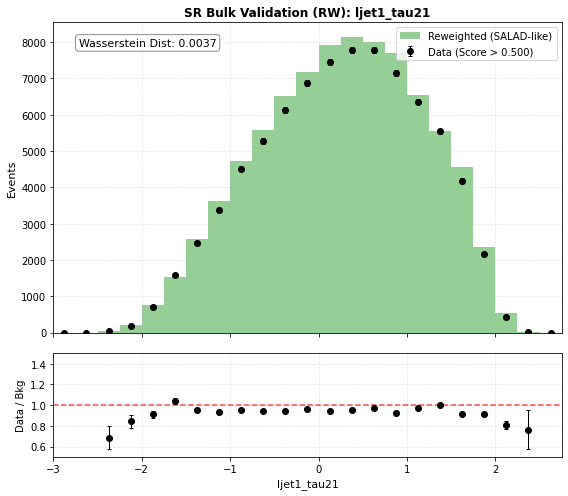

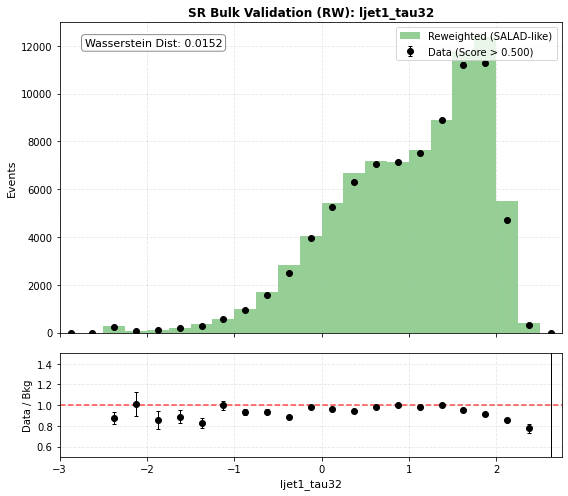

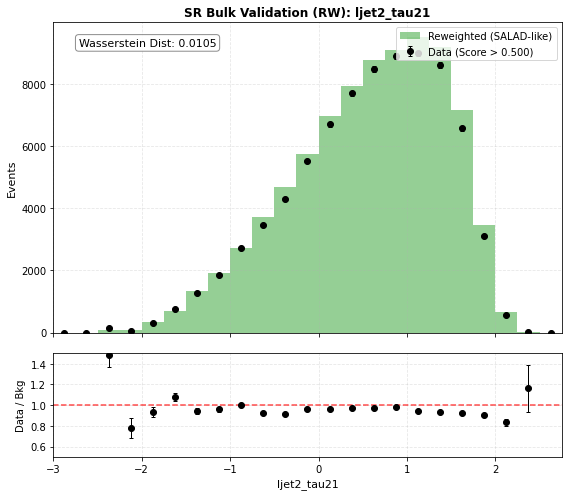

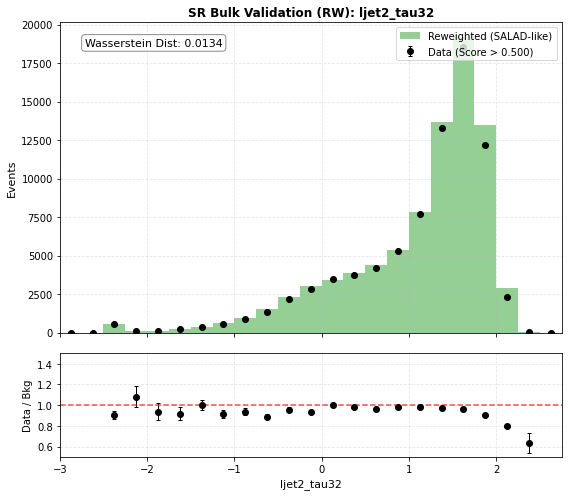

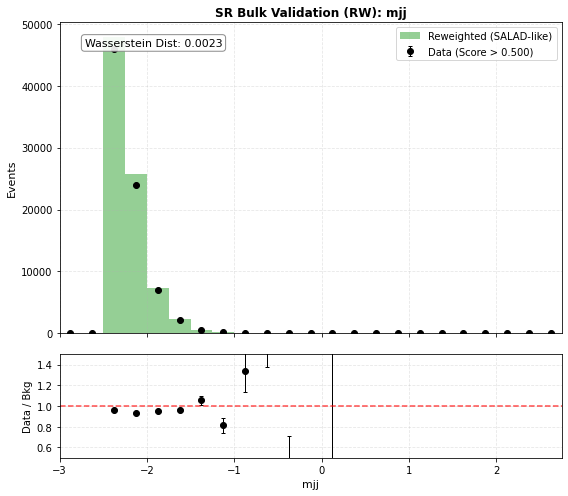

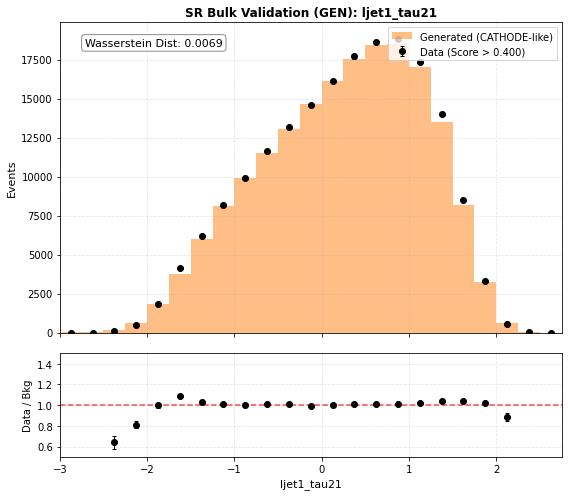

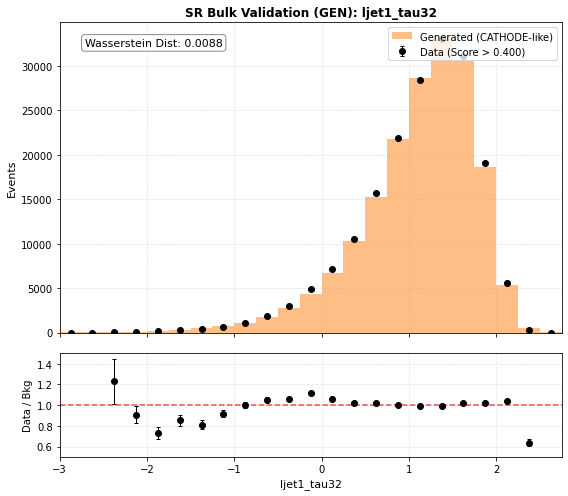

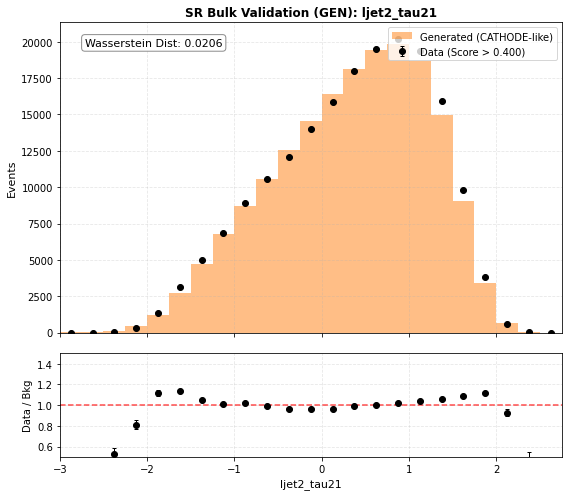

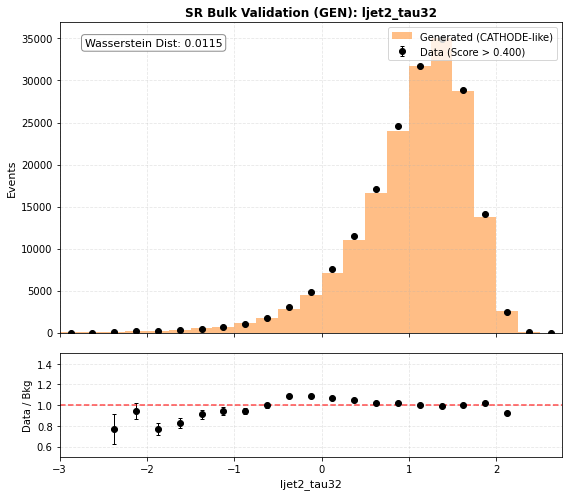

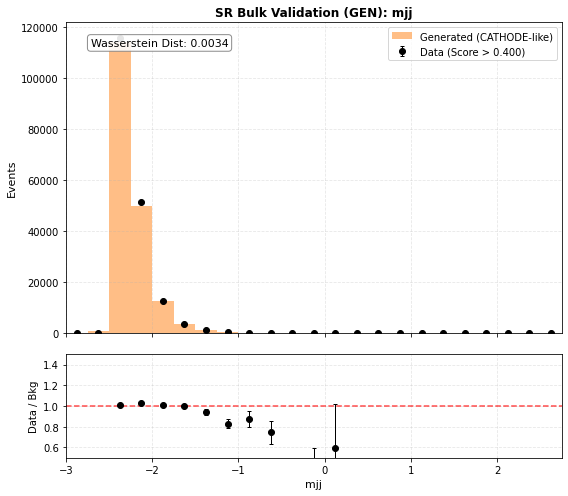

In [14]:
for feat in features_vars:
    plot_sr_closure(df_data, df_mc_rw, bkg_type="RW", feature=feat, threshold=0.5)

for feat in features_vars:
    plot_sr_closure(df_data, df_mc_gen, bkg_type="GEN", feature=feat, threshold=0.4)

In [15]:
def optimize_cut_threshold(df_sig, df_bkg, bkg_type, sig_mode):
    mass = sig_mode.split("_")[0]
    rinv = f"0.{sig_mode.split('_')[1]}"

    if bkg_type == "NOM":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    thresholds = np.linspace(0.001, 0.7, 100)
    
    significances = []
    s_yields = []
    b_yields = []

    for thresh in thresholds:

        s_mask = df_sig[sig_col_score] < thresh
        b_mask = df_bkg[bkg_col_score] < thresh

        S = df_sig.loc[s_mask, "final_weight"].sum()
        B = df_bkg.loc[b_mask, bkg_weight_name].sum()
        

        if B > 0 and S > 0:
            Z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        elif B <= 0 and S > 0:
            Z = 0.0 
        else:
            Z = 0.0
            
        significances.append(Z)
        s_yields.append(S)
        b_yields.append(B)

    max_Z = np.max(significances)
    opt_thresh = thresholds[np.argmax(significances)]
    opt_S = s_yields[np.argmax(significances)]
    opt_B = b_yields[np.argmax(significances)]
    

    fig, ax1 = plt.subplots(figsize=(9, 6))
    
    ax1.plot(thresholds, significances, color='purple', lw=2.5, label=f'Expected Significance (Max: {max_Z:.2f} $\sigma$)')
    ax1.axvline(opt_thresh, color='red', linestyle='--', label=f'Optimal Cut: < {opt_thresh:.4f}')
    
    ax1.set_xlabel("Anomaly Score Threshold (Keep events < Threshold)", fontsize=12)
    ax1.set_ylabel("Significance (Asimov Z)", fontsize=12)
    ax1.set_title(f"Cut Optimization: ({mass},{rinv}) vs {bkg_type}", fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', frameon=True)
    ax1.grid(True, linestyle="--", alpha=0.4)
    
    ax2 = ax1.twinx()
    ax2.plot(thresholds, s_yields, color='blue', linestyle=':', alpha=0.7, label='Signal Yield ($S$)')
    ax2.plot(thresholds, b_yields, color='orange', linestyle=':', alpha=0.7, label='Bkg Yield ($B$)')
    ax2.set_ylabel("Expected Event Yield", fontsize=12)
    ax2.set_yscale('log')
    ax2.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.show()
    

    print("-" * 40)
    print(f"OPTIMAL CUT SUMMARY for ({mass},{rinv}) vs {bkg_type}")
    print("-" * 40)
    print(f"Optimal Threshold: Keep events with score < {opt_thresh:.4f}")
    print(f"Maximum Expected Significance: {max_Z:.2f} sigma")
    print(f"Expected Signal Yield (S): {opt_S:.2f}")
    print(f"Expected Bkg Yield (B): {opt_B:.2f}")
    
    return opt_thresh, max_Z

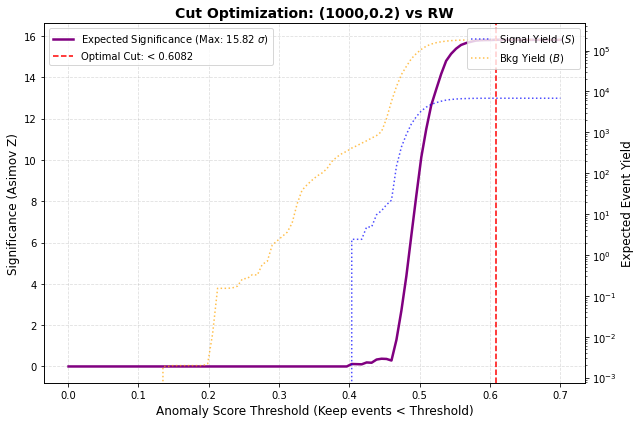

----------------------------------------
OPTIMAL CUT SUMMARY for (1000,0.2) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6082
Maximum Expected Significance: 15.82 sigma
Expected Signal Yield (S): 6815.20
Expected Bkg Yield (B): 183367.85


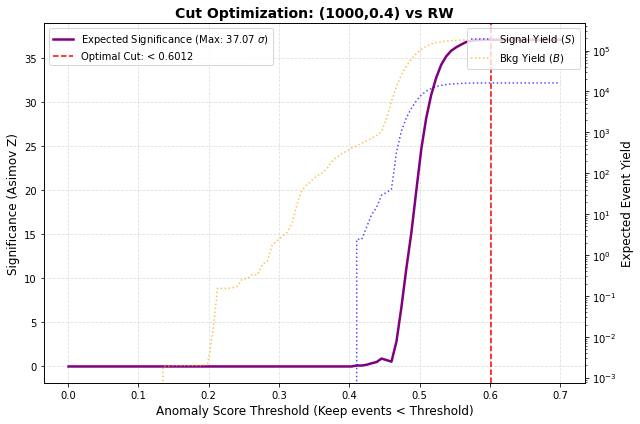

----------------------------------------
OPTIMAL CUT SUMMARY for (1000,0.4) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6012
Maximum Expected Significance: 37.07 sigma
Expected Signal Yield (S): 16099.34
Expected Bkg Yield (B): 183297.10


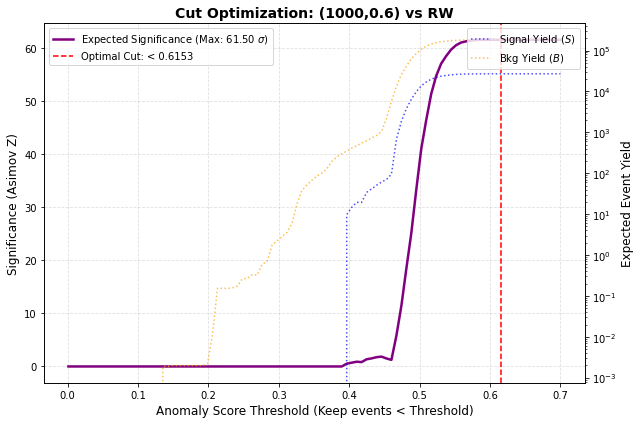

----------------------------------------
OPTIMAL CUT SUMMARY for (1000,0.6) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6153
Maximum Expected Significance: 61.50 sigma
Expected Signal Yield (S): 26962.97
Expected Bkg Yield (B): 183421.75


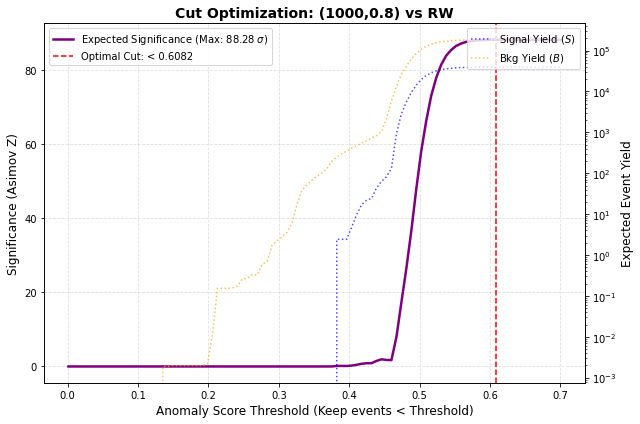

----------------------------------------
OPTIMAL CUT SUMMARY for (1000,0.8) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6082
Maximum Expected Significance: 88.28 sigma
Expected Signal Yield (S): 39080.24
Expected Bkg Yield (B): 183367.85


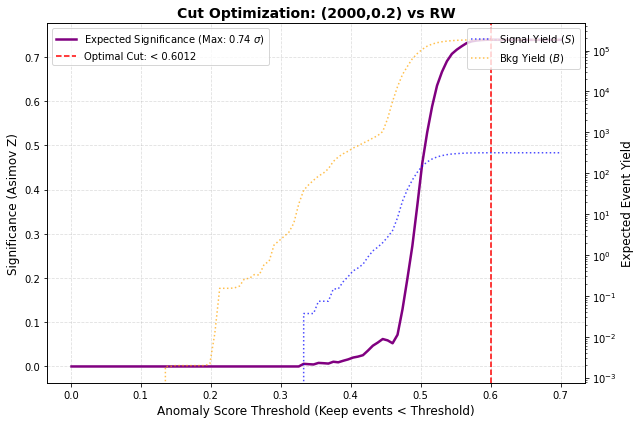

----------------------------------------
OPTIMAL CUT SUMMARY for (2000,0.2) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6012
Maximum Expected Significance: 0.74 sigma
Expected Signal Yield (S): 316.45
Expected Bkg Yield (B): 183297.10


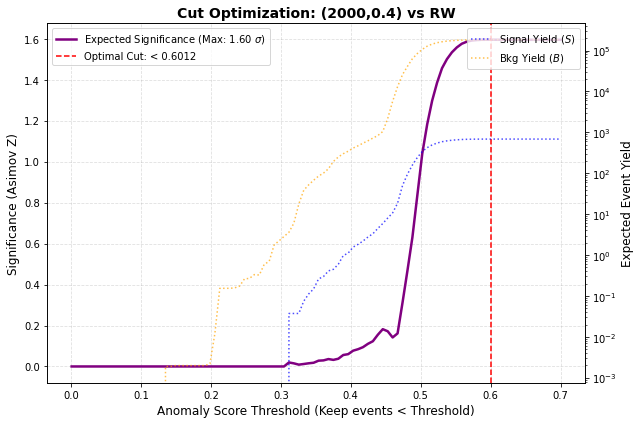

----------------------------------------
OPTIMAL CUT SUMMARY for (2000,0.4) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6012
Maximum Expected Significance: 1.60 sigma
Expected Signal Yield (S): 683.43
Expected Bkg Yield (B): 183297.10


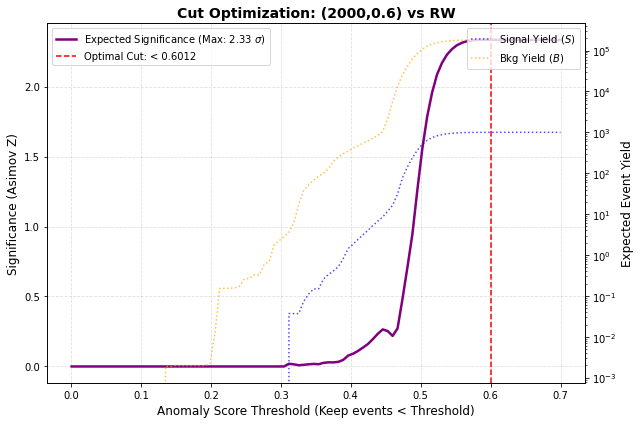

----------------------------------------
OPTIMAL CUT SUMMARY for (2000,0.6) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6012
Maximum Expected Significance: 2.33 sigma
Expected Signal Yield (S): 1000.49
Expected Bkg Yield (B): 183297.10


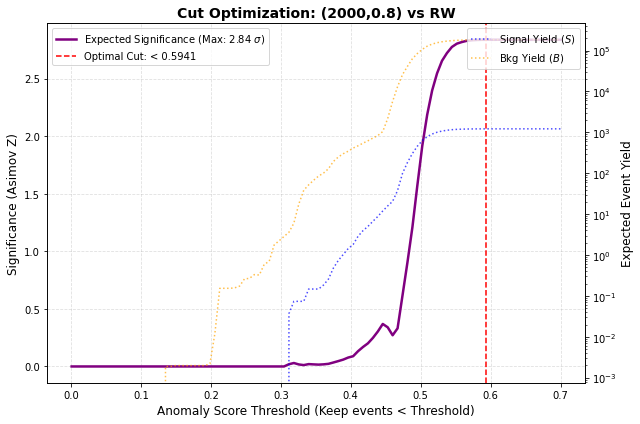

----------------------------------------
OPTIMAL CUT SUMMARY for (2000,0.8) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.5941
Maximum Expected Significance: 2.84 sigma
Expected Signal Yield (S): 1215.72
Expected Bkg Yield (B): 183173.17


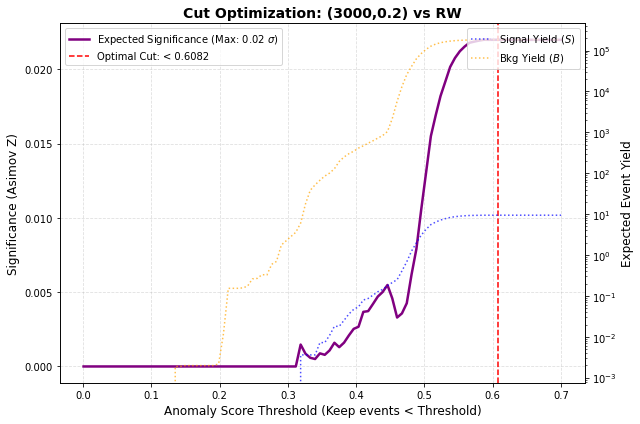

----------------------------------------
OPTIMAL CUT SUMMARY for (3000,0.2) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6082
Maximum Expected Significance: 0.02 sigma
Expected Signal Yield (S): 9.41
Expected Bkg Yield (B): 183367.85


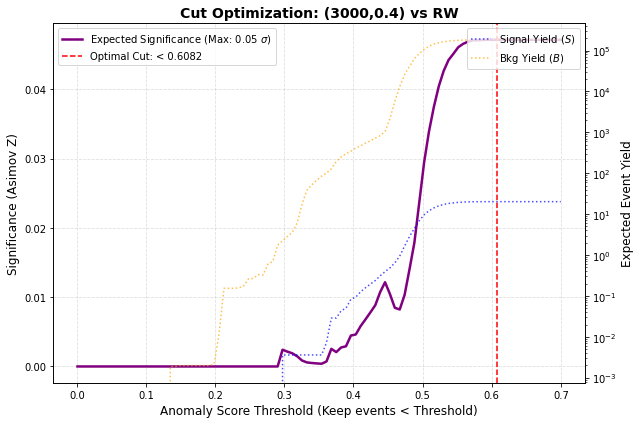

----------------------------------------
OPTIMAL CUT SUMMARY for (3000,0.4) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.6082
Maximum Expected Significance: 0.05 sigma
Expected Signal Yield (S): 20.19
Expected Bkg Yield (B): 183367.85


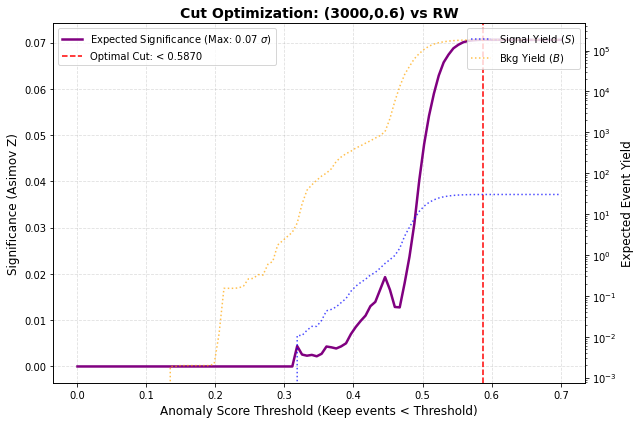

----------------------------------------
OPTIMAL CUT SUMMARY for (3000,0.6) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.5870
Maximum Expected Significance: 0.07 sigma
Expected Signal Yield (S): 30.20
Expected Bkg Yield (B): 182967.22


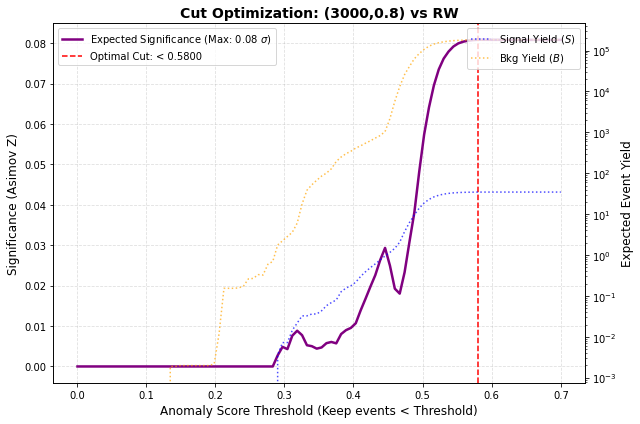

----------------------------------------
OPTIMAL CUT SUMMARY for (3000,0.8) vs RW
----------------------------------------
Optimal Threshold: Keep events with score < 0.5800
Maximum Expected Significance: 0.08 sigma
Expected Signal Yield (S): 34.56
Expected Bkg Yield (B): 182598.97


In [16]:
detector_type = "run2" # default, pu, run2, pu_run2
bkg_type = "RW" # NOM, RW, GEN
df_sig_def = sig_dfs[detector_type]

for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
    else:
        df_mc = df_mc_rw
    
    opt_thresh, max_sig = optimize_cut_threshold(df_sig_def[sig_mode], df_mc, bkg_type, sig_mode)
